# 03 — Advanced

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.ensemble import IsolationForest
from sklearn.linear_model import Ridge

DATA_PATH = Path("../data/raw/GlobalWeatherRepository.csv")
TARGET_CITY = "Kyiv"
REPORTS = Path("../reports")

df = pd.read_csv(DATA_PATH)
df["last_updated"] = pd.to_datetime(df["last_updated"], errors="coerce")
df = df.drop_duplicates(subset=["location_name", "last_updated"], keep="first")

city_df = (
    df.loc[df["location_name"] == TARGET_CITY]
    .sort_values("last_updated")
    .reset_index(drop=True)
)
city_df.shape

(863, 41)

In [2]:
temp = city_df["temperature_celsius"]
rolling_med = temp.rolling(window=30, center=True, min_periods=15).median()
mad = (temp - rolling_med).abs().rolling(window=30, center=True, min_periods=15).median()
robust_z = (temp - rolling_med) / (1.4826 * mad.replace(0, np.nan))

city_df = city_df.assign(robust_z=robust_z)
threshold = 3.5
anomalies = city_df[city_df["robust_z"].abs() > threshold]
print(f"Anomalies (|robust_z| > {threshold}):", len(anomalies))
anomalies[["last_updated", "temperature_celsius", "robust_z"]].head(10)

Anomalies (|robust_z| > 3.5): 9


,last_updated,temperature_celsius,robust_z
0,2024-05-16 11:45:00,13.8,-4.476166
1,2024-05-16 17:00:00,14.6,-4.046945
187,2024-11-20 10:45:00,8.5,4.579437
256,2025-01-28 13:00:00,8.8,3.614252
258,2025-01-30 12:15:00,8.2,3.578931
259,2025-01-31 12:30:00,8.4,3.689052
494,2025-09-23 11:15:00,23.6,3.537895
644,2026-02-21 08:45:00,-17.2,-3.793176
821,2026-08-17 09:00:00,1.1,-4.384190


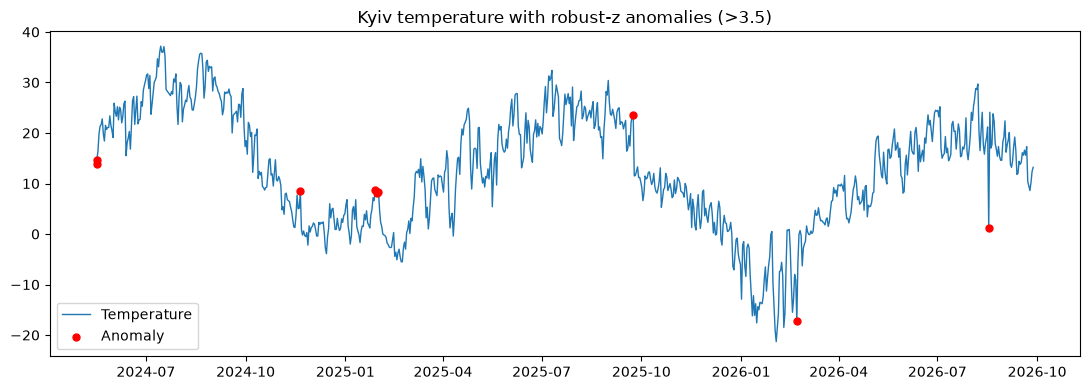

In [3]:
fig, ax = plt.subplots(figsize=(11, 4))
ax.plot(city_df["last_updated"], temp, label="Temperature", linewidth=1)
ax.scatter(
    anomalies["last_updated"], anomalies["temperature_celsius"],
    color="red", s=25, label="Anomaly", zorder=3
)
ax.set_title(f"Kyiv temperature with robust-z anomalies (>{threshold})")
ax.legend()
plt.tight_layout()
plt.savefig(REPORTS / "kyiv_anomalies.png", dpi=150)
plt.show()

In [4]:
feat = city_df[["temperature_celsius", "precip_mm"]].fillna(0)
iso = IsolationForest(contamination=0.02, random_state=42)
city_df["iso_outlier"] = iso.fit_predict(feat) == -1
print("Isolation Forest flags (top 2% by contamination):", city_df["iso_outlier"].sum())


Isolation Forest flags (top 2% by contamination): 18


In [5]:
LAGS = [1, 2, 3, 7, 14, 28]
values = city_df["temperature_celsius"].to_numpy()

def make_lag_matrix(values, lags):
    X, y = [], []
    max_lag = max(lags)
    for i in range(max_lag, len(values)):
        X.append([values[i - lag] for lag in lags])
        y.append(values[i])
    return np.array(X), np.array(y)

X, y = make_lag_matrix(values, LAGS)
ridge = Ridge(alpha=1.0).fit(X, y)

importance = pd.Series(ridge.coef_, index=[f"lag_{lag}" for lag in LAGS]).sort_values(key=abs, ascending=False)
importance

lag_1     0.795588
lag_7     0.093272
lag_14    0.052187
lag_3     0.039809
lag_28   -0.000949
lag_2    -0.000020
dtype: float64

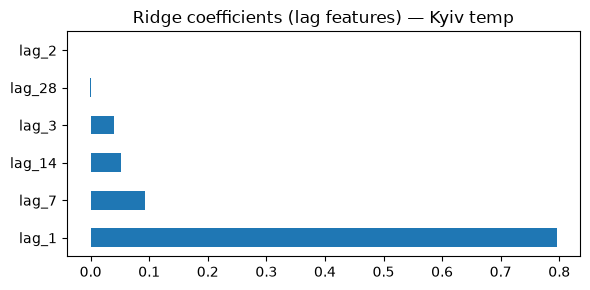

In [6]:
importance.plot(kind="barh", figsize=(6, 3), title="Ridge coefficients (lag features) — Kyiv temp")
plt.tight_layout()
plt.savefig(REPORTS / "kyiv_lag_importance.png", dpi=150)
plt.show()

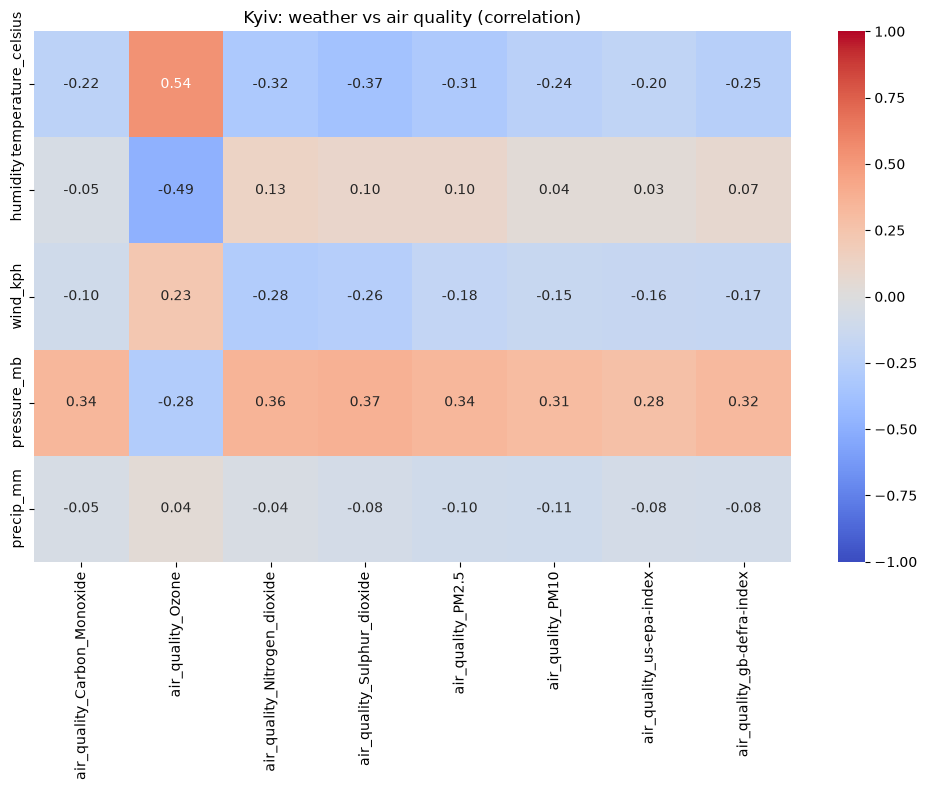

In [7]:
aq_cols = [c for c in df.columns if c.startswith("air_quality")]
weather_cols = ["temperature_celsius", "humidity", "wind_kph", "pressure_mb", "precip_mm"]

# Kyiv rows only — no merge (avoids _x / _y suffixes)
kyiv_full = (
    df.loc[df["location_name"] == TARGET_CITY, weather_cols + aq_cols + ["last_updated"]]
    .sort_values("last_updated")
    .reset_index(drop=True)
)

# Optional: confirm columns exist
# print(kyiv_full.columns.tolist())

corr_block = kyiv_full[weather_cols + aq_cols].corr()
weather_vs_aq = corr_block.loc[weather_cols, aq_cols]

plt.figure(figsize=(10, 8))
sns.heatmap(weather_vs_aq, annot=True, fmt=".2f", cmap="coolwarm", vmin=-1, vmax=1)
plt.title("Kyiv: weather vs air quality (correlation)")
plt.tight_layout()
plt.savefig(REPORTS / "kyiv_air_quality_corr.png", dpi=150)
plt.show()

Countries with >=100 rows: 186


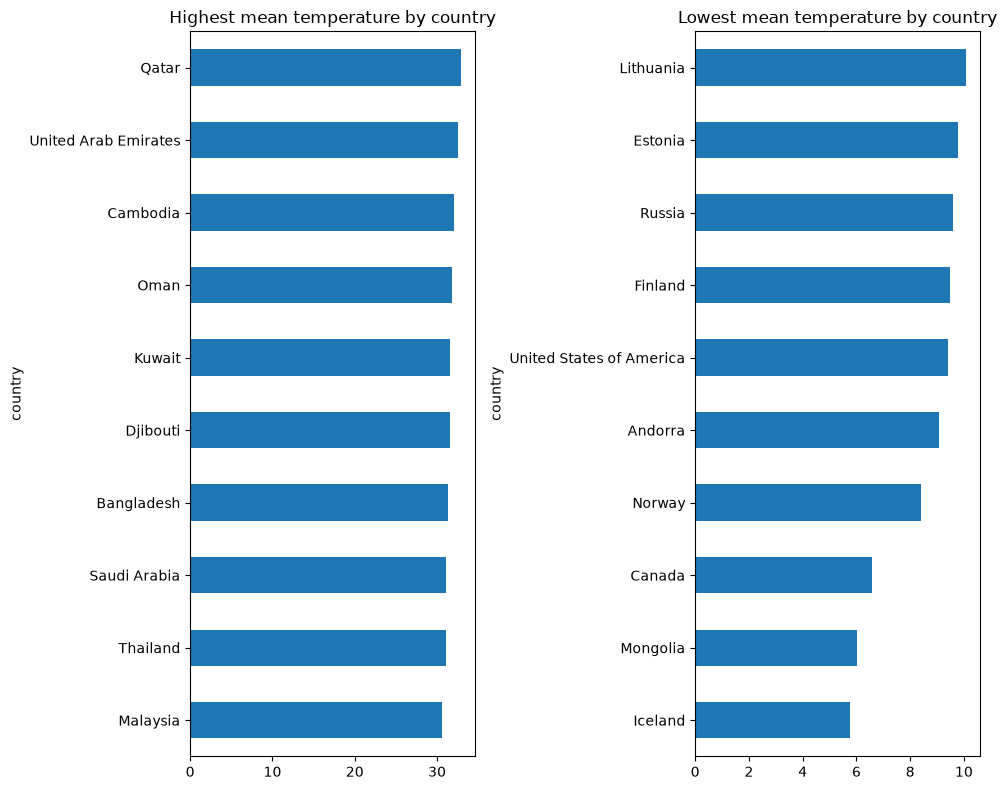

Hottest: ['Qatar', 'United Arab Emirates', 'Cambodia']
Coldest: ['Iceland', 'Mongolia', 'Canada']


In [8]:
MIN_COUNTRY_ROWS = 100
counts = df.groupby("country").size()
countries_ok = counts[counts >= MIN_COUNTRY_ROWS].index
df_geo = df[df["country"].isin(countries_ok)]
print(f"Countries with >={MIN_COUNTRY_ROWS} rows: {len(countries_ok)}")

country_temp = (
    df_geo.groupby("country")["temperature_celsius"]
    .mean()
    .sort_values()
)
top10 = country_temp.tail(10)
bottom10 = country_temp.head(10)

fig, axes = plt.subplots(1, 2, figsize=(10, 8))
top10.plot(kind="barh", ax=axes[0], title="Highest mean temperature by country")
bottom10.plot(kind="barh", ax=axes[1], title="Lowest mean temperature by country")
plt.tight_layout()
plt.savefig(REPORTS / "country_mean_temperature.png", dpi=150)
plt.show()
print("Hottest:", list(top10.index[-3:][::-1]))
print("Coldest:", list(bottom10.index[:3]))



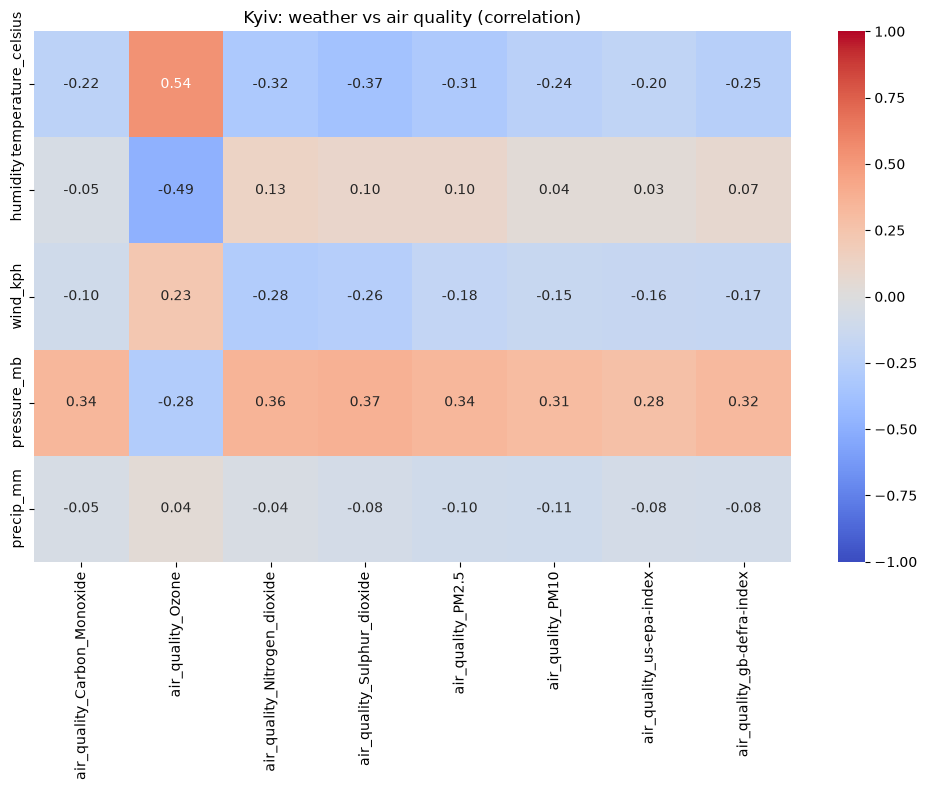

In [9]:
aq_cols = [c for c in df.columns if c.startswith("air_quality")]
weather_cols = ["temperature_celsius", "humidity", "wind_kph", "pressure_mb", "precip_mm"]

kyiv_full = (
    df.loc[df["location_name"] == TARGET_CITY, weather_cols + aq_cols + ["last_updated"]]
    .sort_values("last_updated")
    .reset_index(drop=True)
)

weather_vs_aq = kyiv_full[weather_cols + aq_cols].corr().loc[weather_cols, aq_cols]

plt.figure(figsize=(10, 8))
sns.heatmap(weather_vs_aq, annot=True, fmt=".2f", cmap="coolwarm", vmin=-1, vmax=1)
plt.title("Kyiv: weather vs air quality (correlation)")
plt.tight_layout()
plt.savefig(REPORTS / "kyiv_air_quality_corr.png", dpi=150)
plt.show()

In [10]:
stacked = weather_vs_aq.stack().sort_values(key=abs, ascending=False)
stacked.head(5)

temperature_celsius  air_quality_Ozone               0.538433
humidity             air_quality_Ozone              -0.489225
pressure_mb          air_quality_Sulphur_dioxide     0.373263
temperature_celsius  air_quality_Sulphur_dioxide    -0.370312
pressure_mb          air_quality_Nitrogen_dioxide    0.356393
dtype: float64